# EXPL_03 — Weather Influence

This notebook interprets how the frozen models use **forecast-origin**
temperature, humidity, and station pressure.

This is not the later ±temperature scenario experiment.


In [1]:
# Import libraries
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "explainability.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/explainability.yaml')

In [3]:
# Import modules for generating explainability
from src.ontario_peak_risk.explainability.common import (
    load_explainability_config,
    ensure_phase_directories,
    load_final_metadata,
)

In [4]:
# Load parameters
config, project_root = load_explainability_config(CONFIG_PATH)
phase_paths = ensure_phase_directories(config, project_root)
metadata = load_final_metadata(config, project_root)

print("Project root:", project_root)
print("RF:", metadata["rf"]["algorithm"], "| horizons:", metadata["rf"]["horizons"])
print("XGB:", metadata["xgb"]["algorithm"], "| horizons:", metadata["xgb"]["horizons"])
print("Explainability output:", phase_paths["outputs_dir"])


Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
RF: RandomForestRegressor | horizons: 24
XGB: XGBoostClassifier | horizons: 24
Explainability output: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\explainability


In [5]:
from src.ontario_peak_risk.explainability.weather import (
    weather_shap_summary,
    binned_weather_effect,
)
from src.ontario_peak_risk.explainability.plotting import weather_effect_plot
from src.ontario_peak_risk.explainability.reporting import write_weather_report

In [6]:
# get weather_features
shap_global = pd.read_csv(
    phase_paths["outputs_dir"] / "EXPL_02_shap_global_by_horizon.csv"
)
shap_long = pd.read_parquet(
    phase_paths["outputs_dir"] / "EXPL_02_shap_feature_values.parquet"
)

# Weather analysis requires numeric feature values.
# Recreate the working feature_value column from the Parquet-safe
# numeric representation generated by EXPL_02.
shap_long["feature_value"] = shap_long["feature_value_numeric"]

weather_features = list(config["weather_features"])


In [10]:
# Calculate weather_summary
weather_summary = weather_shap_summary(
    shap_global,
    weather_features,
)
display(weather_summary)

,task,horizon,total_mean_abs_shap,weather_mean_abs_shap,weather_share_pct
0,rf,1,4606.231148,430.272535,9.341097
1,rf,6,4423.671735,330.967595,7.481739
2,rf,12,4415.429003,216.147535,4.895278
3,rf,18,4296.437795,136.828103,3.184687
4,rf,24,4151.461358,97.348707,2.344926
5,xgb,1,12.355498,2.601746,21.057392
6,xgb,6,10.932020,1.914800,17.515518
7,xgb,12,10.364120,1.726466,16.658105
8,xgb,18,9.564064,1.539441,16.096094
9,xgb,24,9.569503,1.482103,15.487772


In [11]:
# Generate weather_binned
binned_parts = []
for feature in weather_features:
    binned = binned_weather_effect(
        shap_long,
        feature,
        bins=10,
    )
    if not binned.empty:
        binned_parts.append(binned)

weather_binned = (
    pd.concat(binned_parts, ignore_index=True)
    if binned_parts else pd.DataFrame()
)
display(weather_binned.head(40))


,task,horizon,feature,value_bin,observations,mean_feature_value,mean_shap,mean_abs_shap
0,rf,1,origin__Temp (°C),"(-12.301, -6.42]",24,-8.658333,240.641928,242.573514
1,rf,1,origin__Temp (°C),"(-6.42, -2.42]",24,-4.250000,140.072768,173.502549
2,rf,1,origin__Temp (°C),"(-2.42, 1.17]",24,-0.766667,13.082264,91.369298
3,rf,1,origin__Temp (°C),"(1.17, 4.78]",24,2.858333,-307.998298,309.344396
4,rf,1,origin__Temp (°C),"(4.78, 8.0]",25,6.280000,-359.436103,359.436103
5,rf,1,origin__Temp (°C),"(8.0, 13.68]",23,10.330435,-433.006004,433.006004
6,rf,1,origin__Temp (°C),"(13.68, 16.93]",24,15.425000,-533.463032,533.463032
7,rf,1,origin__Temp (°C),"(16.93, 20.12]",24,18.670833,-395.736740,395.736740
8,rf,1,origin__Temp (°C),"(20.12, 23.02]",24,21.683333,73.151422,234.265658
9,rf,1,origin__Temp (°C),"(23.02, 32.8]",24,26.512500,1350.297016,1350.297016


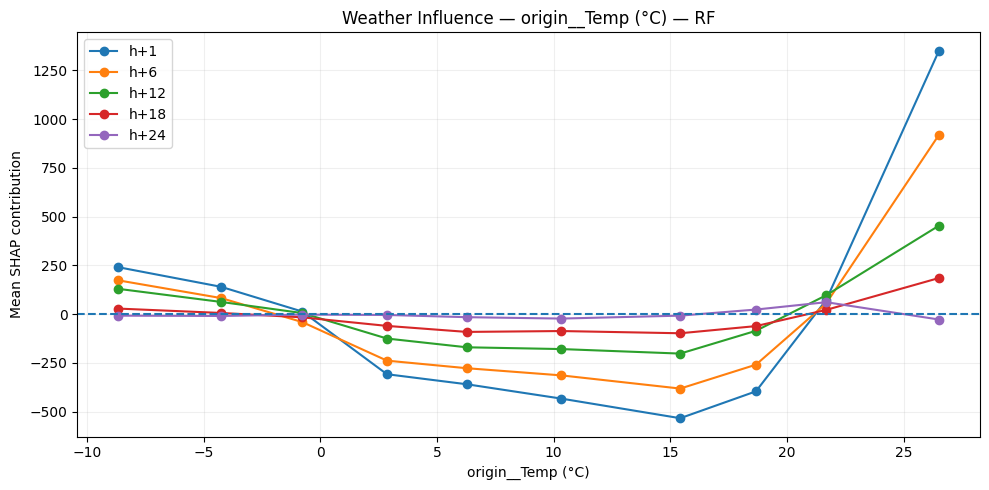

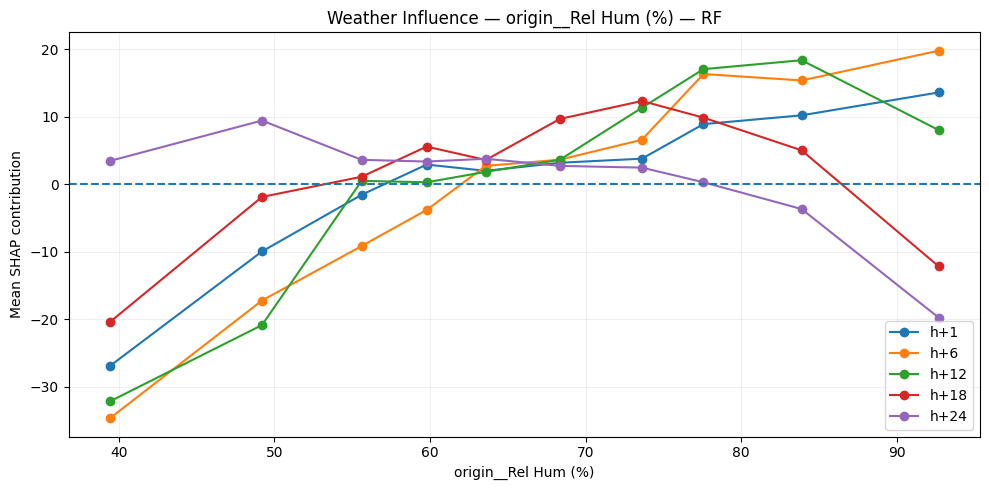

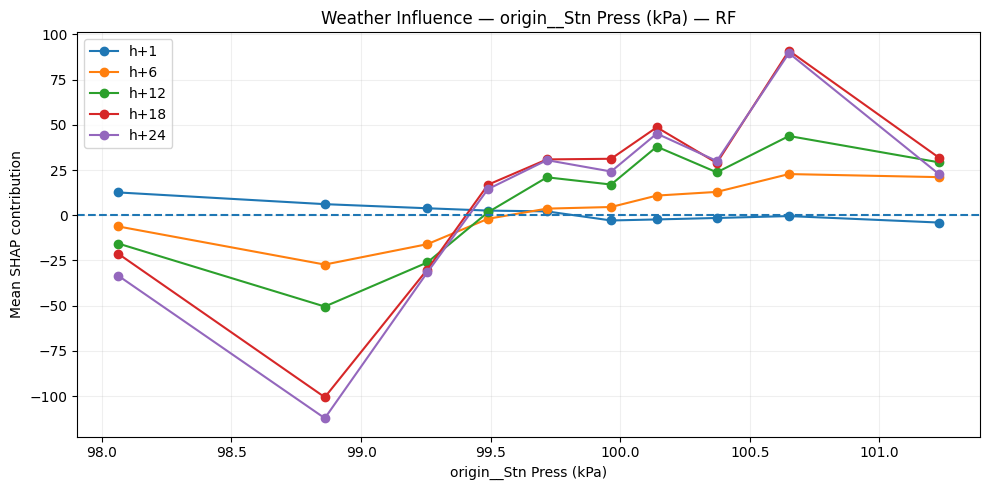

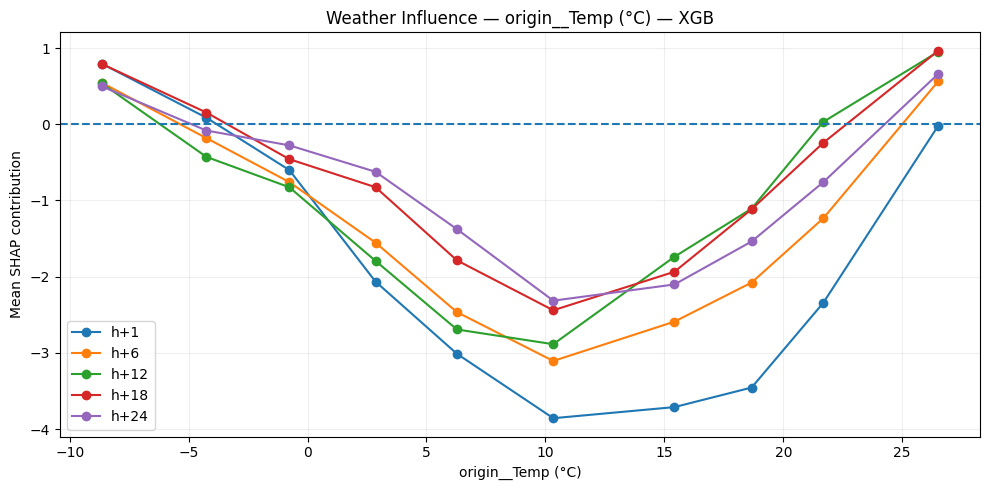

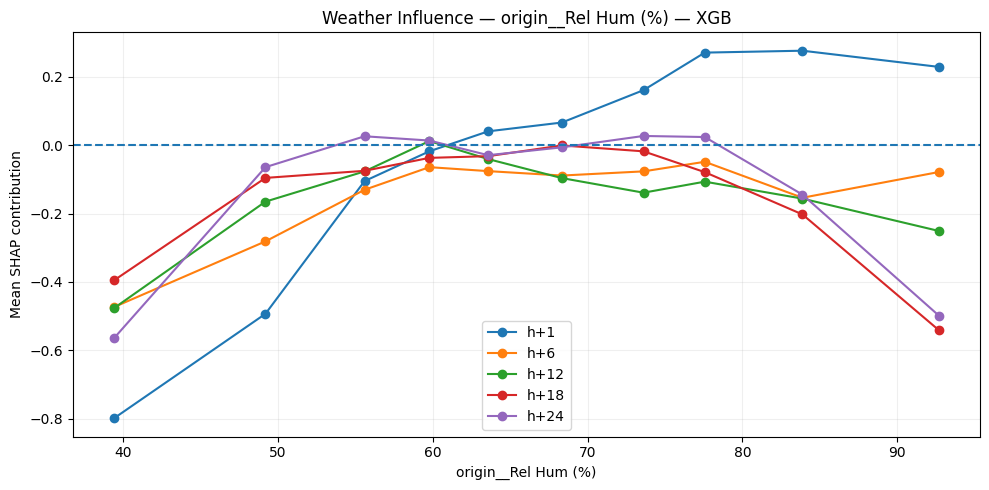

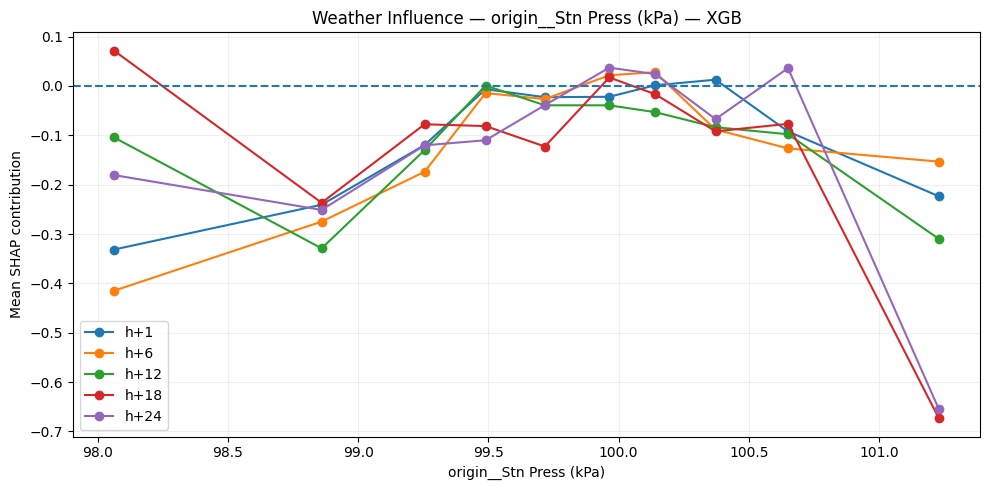

In [12]:
if not weather_binned.empty:
    for task in ["rf", "xgb"]:
        for feature in weather_features:
            if (
                (weather_binned["task"].eq(task))
                & (weather_binned["feature"].eq(feature))
            ).any():
                weather_effect_plot(
                    weather_binned, feature, task
                )
                plt.show()


## Interpretation guidance

A positive SHAP contribution means a weather value pushes the model output
upward relative to its baseline **in the context of the other features**.
A negative contribution pushes it downward.

Do not describe these curves as causal temperature effects.


In [14]:
weather_summary.to_csv(
    phase_paths["outputs_dir"] / "EXPL_03_weather_shap_summary.csv",
    index=False,
)
weather_binned.to_csv(
    phase_paths["outputs_dir"] / "EXPL_03_weather_binned_effects.csv",
    index=False,
)

write_weather_report(
    phase_paths["docs_dir"] / "EXPL_03_Weather_Influence.md",
    weather_summary,
    weather_binned,
)

print("EXPL_03 RESULT: COMPLETE")


EXPL_03 RESULT: COMPLETE
